In [2]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

In [3]:
import tensorflow as tf
import keras

train_ds = keras.utils.image_dataset_from_directory(
    path+"/Training",
    image_size=(224,224),
    batch_size=32,
    label_mode="int"
) 

test_ds = keras.utils.image_dataset_from_directory(
    path+"/Testing",
    image_size=(224,224),
    batch_size=32,
    label_mode="int")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [ ]:
X_train, y_train, X_test, y_test = [], [], [], []

for image, label in train_ds:
	X_train.append(image)
	y_train.append(label)

for image, label in test_ds:
	X_test.append(image)
	y_test.append(label)

X_train = tf.concat(X_train,axis=0) / 255.0
y_train = tf.concat(y_train,axis=0) 
X_test = tf.concat(X_test,axis=0) / 255.0 
y_test = tf.concat(y_test,axis=0)

In [ ]:
len(X_train), len(y_train), len(X_test), len(y_test)

(5600, 5600, 1600, 1600)

(<matplotlib.image.AxesImage at 0x279dec594e0>,
 <tf.Tensor: shape=(), dtype=int32, numpy=0>)

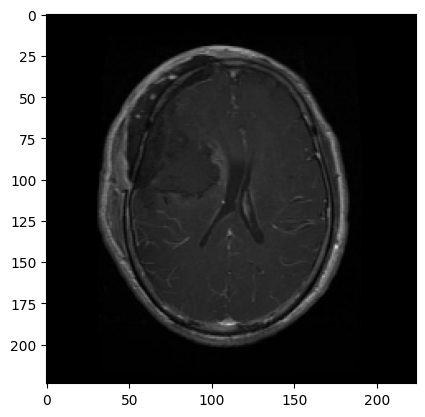

In [ ]:
import matplotlib.pyplot as mtp

mtp.imshow(X_train[0]), y_train[0]

In [ ]:
from keras.callbacks import EarlyStopping 
from keras import Sequential, layers
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3), padding="same"),
	MaxPooling2D((2,2)),

	Conv2D(64,(3,3),activation="relu"),
	MaxPooling2D((2,2)),

	Flatten(),

	Dense(64,activation="relu"),
	Dropout(0.3),
	Dense(32,activation="relu"),
	Dropout(0.3),
	Dense(4,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

AttributeError: module 'keras.src.backend' has no attribute 'RandomGenerator'

In [3]:
%pip list

Package                      Version
---------------------------- ------------
absl-py                      2.4.0
asttokens                    3.0.1
astunparse                   1.6.3
certifi                      2026.4.22
cffi                         2.0.0
charset-normalizer           3.4.7
colorama                     0.4.6
comm                         0.2.3
contourpy                    1.3.2
cryptography                 47.0.0
cycler                       0.12.1
debugpy                      1.8.20
decorator                    5.2.1
exceptiongroup               1.3.1
executing                    2.2.1
flatbuffers                  25.12.19
fonttools                    4.63.0
gast                         0.7.0
google-auth                  2.49.2
google-auth-oauthlib         1.3.1
google-pasta                 0.2.0
grpcio                       1.80.0
h5py                         3.14.0
idna                         3.13
ipykernel                    7.2.0
ipython                      8.39

In [ ]:
%pip uninstall tensorflow

In [ ]:
%pip install tensorflow